### Electric vehicle Market Analytics

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

In [4]:
df = pd.read_csv("ev_market_2026.csv")
df.head()

,brand,model,year,variant,price_usd,battery_capacity_kwh,range_miles,charging_speed_kw,acceleration_0_60_mph,top_speed_mph,...,body_type,cargo_volume_cubic_ft,weight_kg,safety_rating,autopilot_level,country_of_origin,market_segment,annual_sales_units,customer_rating,warranty_years
0,Volkswagen,ID. Buzz,2023,Performance,104880.80,118.7,400.0,234.5,3.04,195.0,...,Truck,54.2,2015.0,4,2,Germany,Luxury,202182,4.00,4
1,Toyota,bZ Compact SUV,2022,Premium,48217.41,58.8,219.0,148.1,5.77,159.0,...,SUV,69.0,1709.0,4,0,Japan,Mid-range,7146,3.56,3
2,GM/Chevrolet,Bolt EV,2024,Premium,49651.12,58.2,225.0,104.9,6.84,148.0,...,Van,77.0,1533.0,4,1,US,Mid-range,16590,3.70,3
3,Kia,Sportage EV,2024,Long Range,38131.56,102.5,349.0,66.5,4.66,176.0,...,SUV,65.8,1935.0,4,2,South Korea,Mid-range,127201,3.81,3
4,Tesla,Model 3,2022,Long Range,144079.87,93.9,314.0,298.5,5.64,165.0,...,SUV,38.3,2229.0,4,2,US,Luxury,196401,3.83,4


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   brand                  2000 non-null   object 
 1   model                  2000 non-null   object 
 2   year                   2000 non-null   int64  
 3   variant                2000 non-null   object 
 4   price_usd              2000 non-null   float64
 5   battery_capacity_kwh   2000 non-null   float64
 6   range_miles            2000 non-null   float64
 7   charging_speed_kw      2000 non-null   float64
 8   acceleration_0_60_mph  2000 non-null   float64
 9   top_speed_mph          2000 non-null   float64
 10  horsepower             2000 non-null   float64
 11  torque_nm              2000 non-null   float64
 12  drive_type             2000 non-null   object 
 13  seating_capacity       2000 non-null   int64  
 14  body_type              2000 non-null   object 
 15  carg

In [8]:
df.describe()

,year,price_usd,battery_capacity_kwh,range_miles,charging_speed_kw,acceleration_0_60_mph,top_speed_mph,horsepower,torque_nm,seating_capacity,cargo_volume_cubic_ft,weight_kg,safety_rating,autopilot_level,annual_sales_units,customer_rating,warranty_years
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,2024.028500,78873.907150,74.662800,261.825500,155.206300,5.630635,164.884500,665.744000,601.311500,5.747000,46.105850,1886.164500,4.377000,1.124500,129653.592000,3.572045,4.579000
std,1.410561,35296.621782,20.082879,71.028238,80.982301,1.417733,20.781244,267.124838,238.706686,1.045245,19.850264,383.772906,0.661127,0.919469,105775.154465,0.270398,1.218812
min,2020.000000,16394.330000,40.000000,150.000000,50.000000,2.500000,118.000000,150.000000,200.000000,2.000000,15.000000,1500.000000,3.000000,0.000000,656.000000,3.000000,3.000000
25%,2023.000000,52325.920000,58.475000,204.000000,90.975000,4.620000,148.000000,442.750000,391.750000,5.000000,28.175000,1570.000000,4.000000,0.000000,44296.500000,3.380000,4.000000
50%,2024.000000,73013.015000,75.100000,261.000000,132.100000,5.670000,165.000000,683.000000,615.500000,5.000000,41.250000,1740.500000,4.000000,1.000000,111188.000000,3.560000,4.000000
75%,2025.000000,99780.157500,87.550000,310.000000,217.300000,6.770000,181.000000,939.250000,845.000000,7.000000,64.700000,2149.500000,5.000000,2.000000,202496.750000,3.750000,5.000000
max,2026.000000,269775.200000,119.900000,447.000000,349.900000,8.000000,200.000000,1000.000000,988.000000,7.000000,80.000000,3000.000000,5.000000,3.000000,499717.000000,4.510000,8.000000


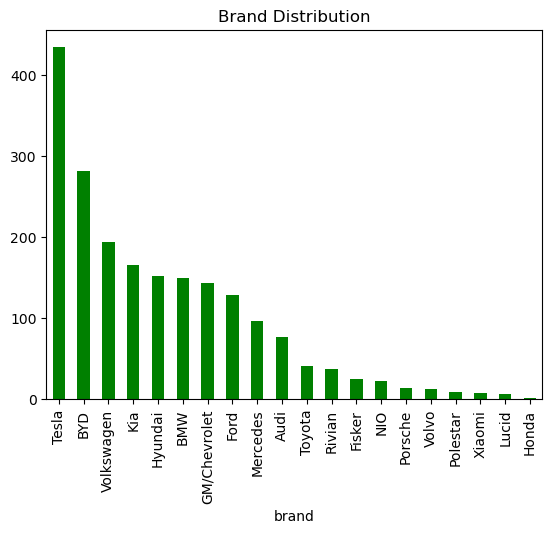

In [12]:
plt.figure()
df['brand'].value_counts().plot(kind='bar', color='green')
plt.title("Brand Distribution")
plt.show()

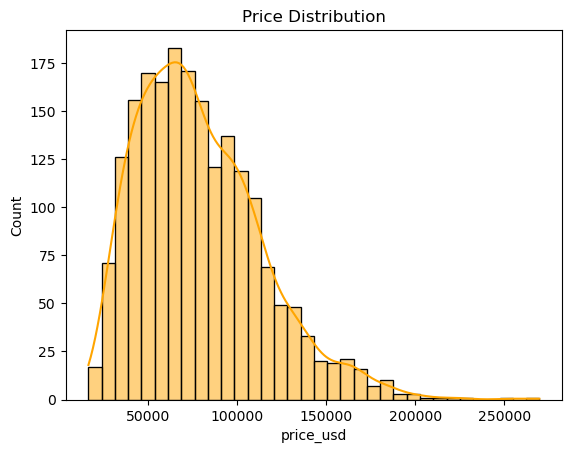

In [14]:
plt.figure()
sns.histplot(df['price_usd'], kde=True, color='orange')
plt.title("Price Distribution")
plt.show()

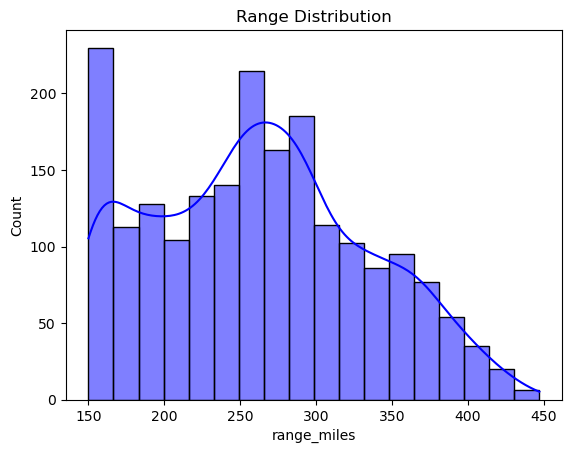

In [16]:
plt.figure()
sns.histplot(df['range_miles'], kde=True, color='blue')
plt.title("Range Distribution")
plt.show()

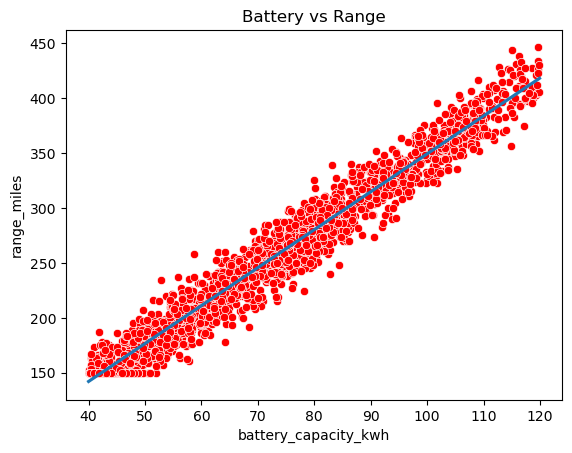

In [18]:
plt.figure()
sns.scatterplot(x='battery_capacity_kwh', y='range_miles', data=df, color='red')
sns.regplot(x='battery_capacity_kwh', y='range_miles', data=df, scatter=False)
plt.title("Battery vs Range")
plt.show()

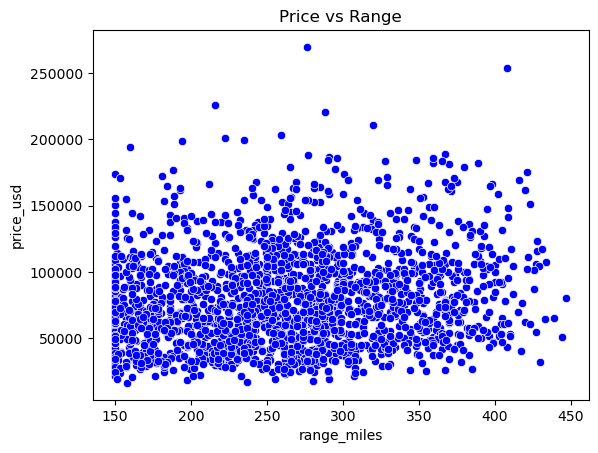

In [24]:
plt.figure()
sns.scatterplot(x='range_miles', y='price_usd', data=df, color='blue')
plt.title("Price vs Range")
plt.show()

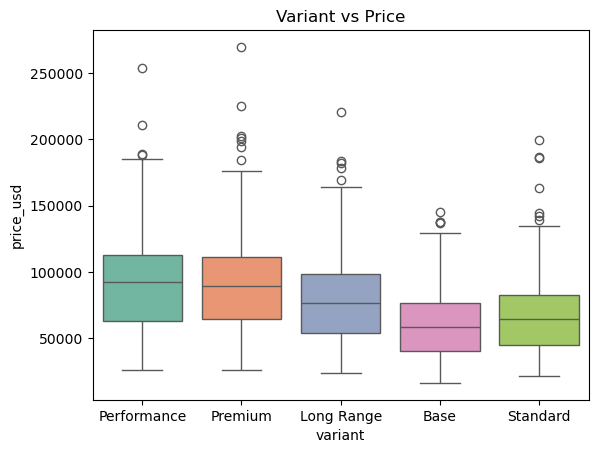

In [26]:
plt.figure()
sns.boxplot(x='variant', y='price_usd', data=df, palette='Set2')
plt.title("Variant vs Price")
plt.show()

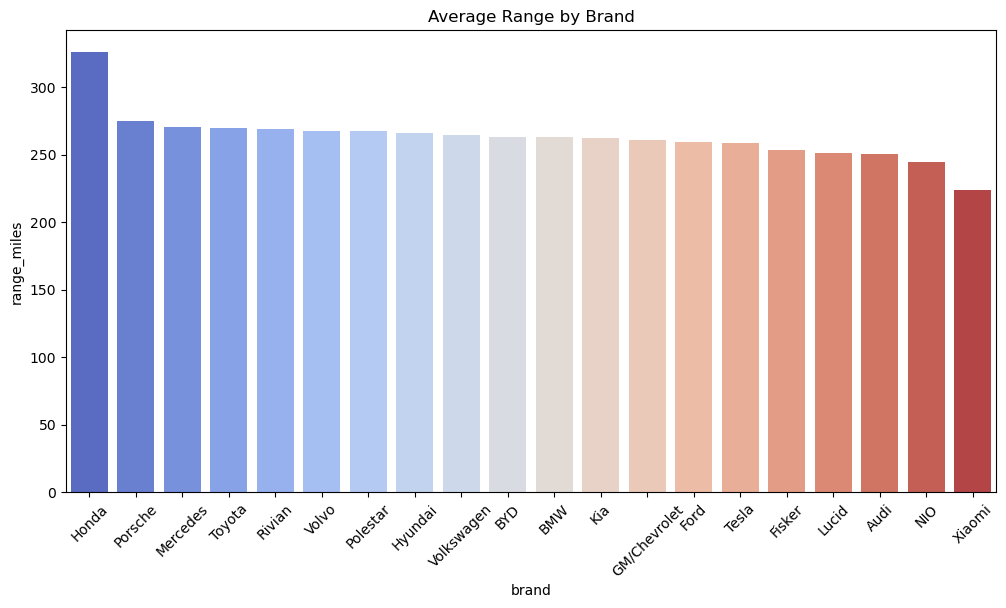

In [32]:
brand_stats = df.groupby('brand')[[
    'price_usd',
    'range_miles',
    'charging_speed_kw',
    'annual_sales_units'
]].mean().reset_index()
brand_stats_sorted = brand_stats.sort_values(by='range_miles', ascending=False)

plt.figure(figsize=(12,6))

sns.barplot(
    data=brand_stats_sorted,
    x='brand',
    y='range_miles',
    palette='coolwarm'
)

plt.xticks(rotation=45)
plt.title("Average Range by Brand")
plt.show()

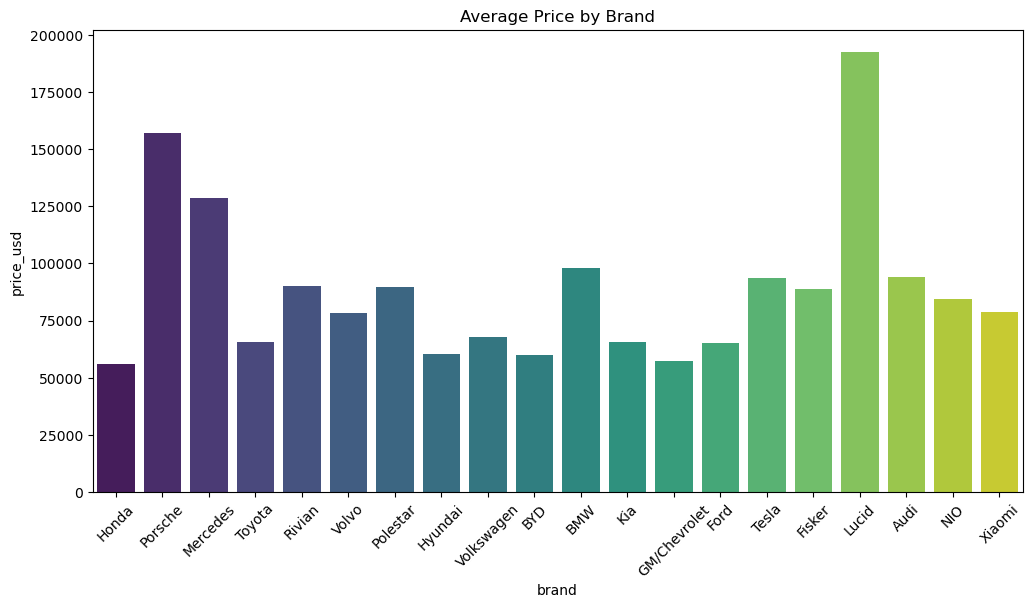

In [34]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=brand_stats_sorted,
    x='brand',
    y='price_usd',
    palette='viridis'
)

plt.xticks(rotation=45)
plt.title("Average Price by Brand")
plt.show()

In [38]:
df['value_score'] = df['range_miles'] / df['price_usd']

top_value = df.sort_values(by='value_score', ascending=False).head(10)

top_value[['brand','model','price_usd','range_miles','value_score']]

,brand,model,price_usd,range_miles,value_score
852,BYD,Qin,17777.32,280.0,0.015750
158,BYD,Seagull,19470.99,291.0,0.014945
1055,BYD,Seagull,16613.01,237.0,0.014266
1533,BYD,Qin,27057.77,385.0,0.014229
124,BYD,Qin,21712.40,307.0,0.014139
1775,BYD,Atto 3,26097.55,367.0,0.014063
1878,BYD,Atto 3,25253.73,355.0,0.014057
830,BYD,Atto 3,31933.47,430.0,0.013465
1021,BYD,Leaf 50X,25921.47,344.0,0.013271
617,BYD,Dolphin,19398.19,255.0,0.013146


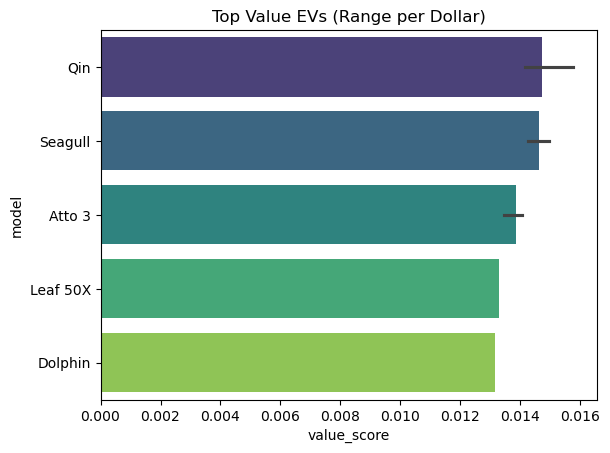

In [40]:
plt.figure()
sns.barplot(x='value_score', y='model', data=top_value, palette='viridis')
plt.title("Top Value EVs (Range per Dollar)")
plt.show()

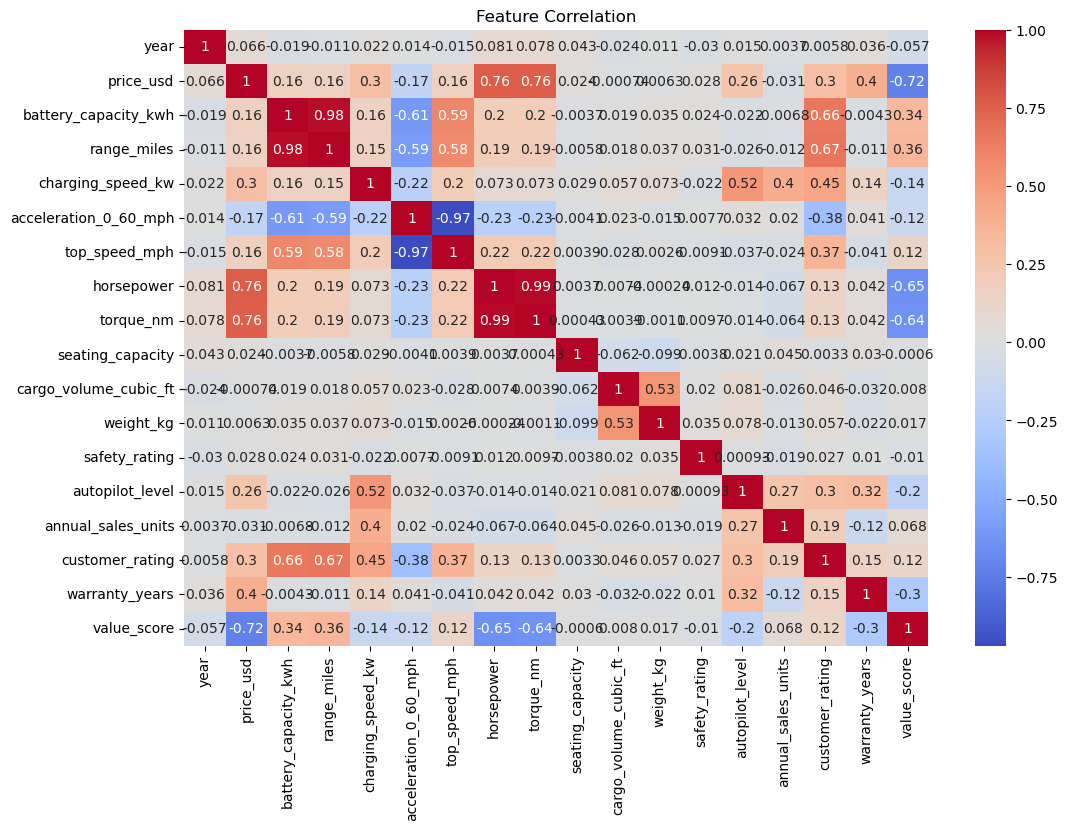

In [42]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()